# Working with CEH-GEAR-1hr rainfall data
## Zarr version using R

<img width="309" height="57" alt="UKCEH and FDRI logos" src="https://github.com/user-attachments/assets/04afdc63-663f-41e4-b29d-9419f78d76c3" />
</br>

**Authors:** [Matt Dalle Piagge](https://mattjbr123.github.io/) and Kit Macleod. With help from: Matt Fry, Mike Brown, Anna Rose Klaptocz, Faiza Samreen, Matt Coole

---

**Launch this notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/pizzarr/notebooks/CEH-GEAR-1hr/gear_zarr_R_stars.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=notebooks/CEH-GEAR-1hr/gear_zarr_R.ipynb)

(Ctrl + Click to open in a new tab)

> **Google Colab:** If running in Google Colab, you will need to switch to an R runtime. Click the "Runtime" menu in the menu bar at the top of the screen, select Change runtime type, select R from the 'Runtime type' drop down box, you can leave the rest the same.

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/fdri-gridded-notebooks/blob/main/README.md#R).

---

## About this notebook

This notebook explores **CEH-GEAR-1hr** (Gridded Estimates of Areal Rainfall — Hourly), a gridded rainfall dataset for Great Britain produced as part of the [FDRI (Floods and Droughts Research Infrastructure)](https://fdri.org.uk) project.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored on S3 storage, a storage medium that is becoming increasingly common for large gridded datasets. Datasets on S3 storage are typically stored in the Zarr format.

**We will:**
1. Show how to open a dataset stored in Zarr format
2. Show how to extract and plot a time series at a single location
3. Show how to plot a map of rainfall at a single time step

**Data store:**
The data is currently publicly available as a trial through JASMIN object storage at the following URL:
```
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr
```

---

## 0. Setup

Install and load the `stars` package and associated libraries. This can take several minutes.

In [17]:
# ── Install packages ──────────────────────────────────────────────────────────
pkgs <- c("stars", "sf", "dplyr", "tidyr", "scales", "lubridate", "ggplot2", "CFtime")
new  <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new) > 0) install.packages(new, repos = "https://cloud.r-project.org", verbose = TRUE)


In [18]:
# ── Load ──────────────────────────────────────────────────────────────────────
suppressPackageStartupMessages({
  library(stars)            # Spatiotemporal arrays / data cubes
  library(sf)               # Spatial features
  library(dplyr)            # Data wrangling
  library(tidyr)
  library(scales)           # Axis formatting
  library(lubridate)        # Date handling
  library(ggplot2)          # Plotting
})

cat("stars version:", as.character(packageVersion("stars")), "\n")


stars version: 0.7.2 


---
## 1. Open the Zarr store

`stars` reads Zarr stores via GDAL's multidimensional array API (`read_mdim()`). GDAL's Zarr driver supports HTTP stores directly using the `/vsicurl/` virtual filesystem prefix, so no credentials or local download are needed for public stores. Here, we read in all the dataset metadata.

In [19]:
# ── Store URL ─────────────────────────────────────────────────────────────────
store_url <- "https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr"

# Build the GDAL Zarr connection string
# read_mdim() uses GDAL's multidimensional array API, which handles time and
# all coordinate dimensions natively
gdal_url <- paste0('ZARR:"/vsicurl/', store_url, '"')

info <- gdal_utils("mdiminfo", gdal_url, quiet = TRUE)
info_json <- jsonlite::fromJSON(info, simplifyVector = FALSE)

print(info_json)

$type
[1] "group"

$driver
[1] "Zarr"

$name
[1] "/"

$attributes
$attributes$Conventions
[1] "CF-1.6"

$attributes$acknowledgement
[1] "This research forms part of the SINATRA project which is supported by the United Kingdom NERC Flooding from Intense Rainfall programme (grant NE/K00896X/1) and an associated knowledge exchange award. It was also funded as part of the CONVEX project which was supported by the United Kingdom NERC Changing Water Cycle programme (grant NE/I006680/1) and the INTENSE project through the European Research Council (grant ERC-2013-CoG-617329). The update of CEH-GEAR-1hr (version 2) was funded by NERC Hydro?JULES programme (grant NE/S017380/1)"

$attributes$cdm_data_type
[1] "Grid"

$attributes$contributor_name
[1] "Lewis, E., Quinn, N., Blenkinsop, S., Fowler, H.J., Freer, J., Tanguy, M., Hitt, O., Coxon, G., Bates, P., Woods, R., Fry, M., Chevuturi, A., Swain, O., White, S.M."

$attributes$coordinates
[1] "time_bnds x_bnds y_bnds"

$attributes$creator_email
[

---
## 2. Get more specific variable information

Look specifically at the rainfall_amount variable's attributes (metadata)

In [20]:
# Navigate to the variable's attributes
var_attrs <- info_json$arrays$rainfall_amount$attributes
print(var_attrs)

$coordinates
[1] "lon lat"

$grid_mapping
[1] "crs"

$long_name
[1] "Gridded estimates of hourly rainfall"

$standard_name
[1] "rainfall_amount"

$valid_max
[1] 500

$valid_min
[1] 0



### Show variable dimensions


In [21]:
dataset <- read_mdim(gdal_url, variable = "rainfall_amount", proxy=TRUE)

# ── Show dataset dimensions and basic metadata ───────────────────────────────
dims <- st_dimensions(dataset)
print(dims)

     from     to         offset   delta  refsys x/y
x       1    701           -500    1000      NA [x]
y       1   1251        1250500   -1000      NA [y]
time    1 236688 1990-01-01 UTC 1 hours POSIXct    


### Read coordinate arrays

Adjust the variables after the function definition below to match what dataset$arrays printed above, to print out the coordinates

In [22]:
# ── Extract coordinate vectors from st_dimensions() ─────────────────────────
# stars stores coordinate values directly in the dimension metadata;
# no need to read them as separate arrays

dims <- st_dimensions(dataset)

xs      <- st_get_dimension_values(dataset, "x")
ys      <- st_get_dimension_values(dataset, "y")
datetimes <- st_get_dimension_values(dataset, "time")

# stars decodes CF time automatically — datetimes is already a POSIXct vector
cat(sprintf("x   : %d values, %.3f to %.3f\n",
  length(xs), min(xs), max(xs)))
cat(sprintf("y   : %d values, %.3f to %.3f\n",
  length(ys), min(ys), max(ys)))
cat(sprintf("Time: %d steps, from %s to %s\n",
  length(datetimes), format(min(datetimes)), format(max(datetimes))))


x   : 701 values, 0.000 to 700000.000
y   : 1251 values, 0.000 to 1250000.000
Time: 236688 steps, from 1990-01-01 to 2016-12-31 23:00:00


---
## 3. Time series at a single grid point

`stars` uses GDAL's `/vsicurl/` HTTP range request support under the hood, so only the chunks covering the requested subset are fetched from the cloud store. We select a single (x, y) point across time using `filter()` on the dimension coordinates — this is the stars equivalent of xarray's `.sel()`in python

**A brief note on chunking:** This store uses 15-day × 100km chunks (as indicated in the filename). A single point time series will download only the chunks that contain the data we've requested.


In [23]:
# ── Choose a target location ──────────────────────────────────────────────────
# E.g. Edinburgh, Scotland (British National Grid)
target_x <- 325000
target_y <- 673000

# Find the nearest grid cell coordinate values
nearest_x <- xs[which.min(abs(xs - target_x))]
nearest_y <- ys[which.min(abs(ys - target_y))]

cat(sprintf("Target location  : x=%.0f, y=%.0f\n", target_x, target_y))
cat(sprintf("Nearest grid cell: x=%.0f, y=%.0f\n", nearest_x, nearest_y))


Target location  : x=325000, y=673000
Nearest grid cell: x=325000, y=673000


Read the first 1000 time steps for this grid cell

In [24]:
# ── Read the time series for this grid cell using coordinate-based selection ──
# stars' filter() selects by coordinate *values* (like xarray's .sel()),
# and slice() selects by index position (like xarray's .isel()).
# Here we combine both: filter to our x/y point, slice the first 1000 time steps.

n_time <- 1000
time_subset <- datetimes[1:n_time]

cat(sprintf("Reading %d time steps for grid cell [x=%.0f, y=%.0f]...\n",
  n_time, nearest_x, nearest_y))

# Read only the needed subset — GDAL fetches only the relevant chunks
ts_stars <- read_mdim(
  gdal_url,
  variable = "rainfall_amount",
  nxy      = c(1L, 1L),             # single grid cell
  offset   = c(
    which.min(abs(xs - target_x)) - 1L,
    which.min(abs(ys - target_y)) - 1L,
    0L
  ),
  count    = c(1L, 1L, n_time)
)

# Extract values and build a tidy data frame
ts_vals <- as.numeric(ts_stars[[1]])

ts_df <- data.frame(
  datetime = st_get_dimension_values(ts_stars, "time"),
  value    = ts_vals
)
tail(ts_df)


Reading 1000 time steps for grid cell [x=325000, y=673000]...


,datetime,value
,<dbl>,<dbl>
995,995,0
996,996,0
997,997,0
998,998,0
999,999,0
1000,1000,0


Plot it

Warning message in scale_x_datetime(labels = scales::date_format("%b %Y")):
“A <numeric> value was passed to a Datetime scale.
ℹ The value was converted to a <POSIXct> object.”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_line()`).”


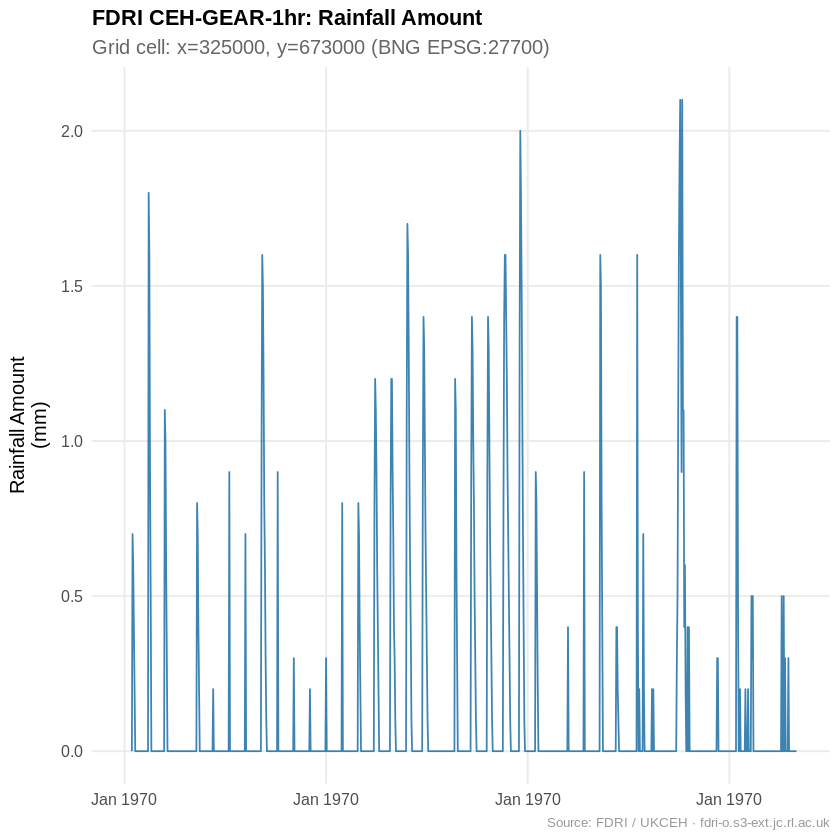

In [25]:
# ── Plot: full time series ────────────────────────────────────────────────────
y_label     <- if (nchar(var_units) > 0) paste0(var_long, "\n(", var_units, ")") else var_long
subtitle_ts <- sprintf("Grid cell: x=%.0f, y=%.0f (BNG EPSG:27700)", nearest_x, nearest_y)

p_ts <- ggplot(ts_df, aes(x = datetime, y = value)) +
  geom_line(colour = "#1d6fa4", linewidth = 0.5, alpha = 0.85) +
  scale_x_datetime(labels = scales::date_format("%b %Y")) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title    = paste("FDRI CEH-GEAR-1hr:", var_long),
    subtitle = subtitle_ts,
    x        = NULL,
    y        = y_label,
    caption  = "Source: FDRI / UKCEH · fdri-o.s3-ext.jc.rl.ac.uk"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold", size = 13),
    plot.subtitle    = element_text(colour = "grey40"),
    panel.grid.minor = element_blank(),
    plot.caption     = element_text(colour = "grey60", size = 8)
  )

print(p_ts)


---
## 4. Spatial map at a single time step

Read the full spatial grid for one time step. GDAL's `/vsicurl/` support means only the chunks for this single time step are fetched — much more efficient than downloading the entire array.

You are however likely to run into memory issues on Binder which is limited to 2GB of RAM. Try extracting out only a portion of the whole 2D slice.


In [26]:
# ── Choose a time step and read the 2D spatial slice ────────────────────────
t_index    <- 1000L   # 1000th time step; change as needed
slice_time <- format(datetimes[t_index], "%Y-%m-%d %H:%M UTC")
cat(sprintf("Reading spatial slice for time step %d: %s\n", t_index, slice_time))

# Read the full x/y grid for a single time step
# offset and count index into [x, y, time] — only 1 time step is fetched
slice_stars <- read_mdim(
  gdal_url,
  variable = "rainfall_amount",
  offset   = c(0L, 0L, t_index - 1L),
  count    = c(length(xs), length(ys), 1L)
)

cat(sprintf("Grid: %d x × %d y\n", length(xs), length(ys)))
cat(sprintf("Value range: %.3f to %.3f %s\n",
  min(slice_stars[[1]], na.rm = TRUE),
  max(slice_stars[[1]], na.rm = TRUE),
  var_units))


Reading spatial slice for time step 1000: 1990-02-11 15:00 UTC
Grid: 701 x × 1251 y
Value range: 0.000 to 16.300 mm


To plot this nicely, several plotting libraries need to be installed. This can take upwards of 15 minutes. There are slight variations in how this needs to be done for different platforms. Follow the instructions and run the cells **only** for the platform you are currently running the notebook on.

#### Google Colab

In [27]:
# Set up r2u for installing terra (uses precompiled binaries to bypass gdal problems)
download.file(
  "https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_focal.sh",
  "add_cranapt_focal.sh"
)
Sys.chmod("add_cranapt_focal.sh", "0755")
system("./add_cranapt_focal.sh")

#### JASMIN Notebook Service

JASMIN sometimes fails to find the proj directory, which contains the files needed for spatial plotting, meaning you have to set it manually. If you have followed the instructions for the JASMIN Notebook Service on the README, the proj directory should be installed in the directory written out in the commands below. You will need to replace "USERNAME" with your JASMIN username and "ENVNAME" with the name of the environment you created with conda when cloning the jasR environment (this is fdriR if you've followed the instructions word for word).

In [ ]:
# only needs to be run on the JASMIN Notebook Service.

proj_dir <- "/gws/ssde/j25b/fdri/envs/fdricombo/share/proj"
Sys.setenv(PROJ_DATA = file.path(proj_dir))
Sys.setenv(PROJ_LIB = file.path(proj_dir))

To check you have set this correctly, the following command should pass (i.e. not produce an error):

In [ ]:
stopifnot(file.exists(file.path(Sys.getenv("PROJ_DATA"), "proj.db")))

If it produces an error, it is likely proj_dir and thus PROJ_DATA is not correct. You can see what PROJ_DATA is with the below command. Double check proj_dir is set correctly.

In [ ]:
Sys.getenv("PROJ_DATA")

#### Binder

All packages are already set up and installed on Binder, no further configuration is required.

### All platforms - Install libraries

Packages will only be installed if they are not already.

In [ ]:
pkgs <- c("rnaturalearth", "rnaturalearthdata")
new  <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new) > 0) install.packages(new, repos = "https://cloud.r-project.org", verbose = TRUE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

system (cmd0): /usr/lib/R/bin/R CMD INSTALL

also installing the dependency ‘terra’


foundpkgs: terra, rnaturalearth, rnaturalearthdata, /tmp/RtmpqHEg26/downloaded_packages/terra_1.9-27.tar.gz, /tmp/RtmpqHEg26/downloaded_packages/rnaturalearth_1.2.0.tar.gz, /tmp/RtmpqHEg26/downloaded_packages/rnaturalearthdata_1.0.0.tar.gz

files: /tmp/RtmpqHEg26/downloaded_packages/terra_1.9-27.tar.gz, 
	/tmp/RtmpqHEg26/downloaded_packages/rnaturalearth_1.2.0.tar.gz, 
	/tmp/RtmpqHEg26/downloaded_packages/rnaturalearthdata_1.0.0.tar.gz



In [ ]:
library('ggplot2')
library('rnaturalearth')
library('rnaturalearthdata')


### Plot

In [ ]:
# ── Plot the spatial slice using stars + ggplot2 ─────────────────────────────
# geom_stars() renders a stars object directly in ggplot2
# Drop the singleton time dimension so we have a clean 2D raster
slice_2d <- adrop(slice_stars)

# Get GB/Ireland coastline for overlay, transformed to BNG
gb <- ne_countries(country = c("United Kingdom", "Ireland"),
                   scale = "medium", returnclass = "sf") |>
  st_transform(st_crs(slice_2d))

p_map <- ggplot() +
  geom_stars(data = slice_2d) +
  geom_sf(data = gb, fill = NA, colour = "grey30", linewidth = 0.3) +
  scale_fill_distiller(
    palette   = "YlGnBu",
    direction = 1,
    name      = var_units,
    na.value  = "grey90",
    labels    = scales::comma
  ) +
  coord_sf(expand = FALSE) +
  labs(
    title    = paste("FDRI GEAR-Hourly:", var_long),
    subtitle = slice_time,
    x = "Easting", y = "Northing",
    caption  = "Source: FDRI / UKCEH · fdri-o.s3-ext.jc.rl.ac.uk"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title      = element_text(face = "bold"),
    plot.subtitle   = element_text(colour = "grey40"),
    legend.position = "right",
    panel.grid      = element_line(colour = "grey80", linewidth = 0.2),
    plot.caption    = element_text(colour = "grey60", size = 8)
  )

print(p_map)


---
## Appendix

### Troubleshooting

| Symptom | Fix |
|---------|-----|
| `read_mdim()` errors with "no such file" | Check the GDAL Zarr URL format: must be `ZARR:"/vsicurl/https://..."` |
| Variable name not found | Run `gdal_utils("mdiminfo", gdal_url)` to see available variables; update the `variable =` argument |
| Map looks blank or all NA | Check `offset` and `count` values match the actual array dimension order |
| Time values look wrong | `stars` decodes CF time automatically; check `st_get_dimension_values(dataset, "time")` |
| Data is slow to extract | Expected over HTTP for large slices; GDAL fetches only the needed chunks but chunk size affects speed |
| Runtime crashes due to lack of RAM | Reading large slices can exhaust memory on Binder (2GB limit). Try a smaller `count` value or use the Python version of this notebook |


---

**Data citation:** CEH-GEAR-1hr, UKCEH. https://doi.org/10.5285/dbf13dd5-90cd-457a-a986-f2f9dd97e93c